# 59 - Level 1 Probabilistic Speckle-Adaptive UltraTimTrack

Proof-of-concept notebook for a first probabilistic/adaptive UltraTimTrack variant. The working fixed-R UltraTimTrack pipeline is not rewritten. Instead, we compute local speckle/block-matching confidence inside the fascicle ROI/muscle band and use it to adapt the 2-state Kalman measurement covariance.

Adaptive measurement covariance:

`R_geo,t = R_geo,0 * R_scale_t`

`R_scale_t = clip(1 + lambda_geo * (1 - c_t)^2, 1, 20)`

## 1. Imports and Project Setup

Repository map used by this notebook:

- Video loading: `ultrasound_tracker.ultratrack_klt.read_gray_frames`, OpenCV `VideoCapture`.
- ROIs: `data/rois/UltraTimTrack_test_rois.json`, `ultrasound_tracker.roi` for interactive selection in scripts.
- Current UltraTimTrack runner: `scripts/run_strict_ultratimtrack_video.py`.
- Kalman filtering: `ultrasound_tracker.ultratimtrack_matlab_2state.run_matlab_2state_kalman`.
- Saved fixed-R baseline: `results/strict_ultratimtrack_runs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz`.
- Exports: CSV/NPZ written in this notebook's result folder.

In [1]:
from __future__ import annotations

import csv
import json
import sys
from dataclasses import replace
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.ultratimtrack_matlab_2state import (
    MatlabTwoStateKalmanConfig,
    run_matlab_2state_kalman,
)
from ultrasound_tracker.ultratrack_klt import read_gray_frames

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
STRICT_BASELINE = ROOT / 'results' / 'strict_ultratimtrack_runs' / 'UltraTimTrack_test' / 'UltraTimTrack_test_strict_results.npz'
UTT_EXPORT = Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat')
OUT = ROOT / 'results' / 'notebook59_probabilistic_speckle_adaptive_R'
OUT.mkdir(parents=True, exist_ok=True)

# Proof-of-concept window. Set to None to compute confidence for the full sequence.
MAX_SECONDS = 30.0
FORCE_RECOMPUTE_CONFIDENCE = False

for path in [VIDEO, ROI_PATH, STRICT_BASELINE, UTT_EXPORT]:
    print(path, 'OK' if path.exists() else 'MISSING')

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 OK
/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json OK
/Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz OK
/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat OK


## 2-4. Load Video, ROIs, and Fixed-R UltraTimTrack Baseline

The fixed-R result is loaded from the current working strict runner output. This preserves the current UltraTimTrack behavior and avoids recomputing TimTrack/Hough/KLT in this exploratory notebook.

In [2]:
def video_info(path: Path) -> tuple[float, int, int, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ok, frame0 = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f'Could not read first frame from {path}')
    return fps, n_frames, int(frame0.shape[0]), int(frame0.shape[1])


with ROI_PATH.open('r', encoding='utf-8') as f:
    rois = json.load(f)
fascicle_roi = tuple(int(v) for v in rois['fascicle'])

fps, video_n_frames, image_h, image_w = video_info(VIDEO)
baseline = np.load(STRICT_BASELINE, allow_pickle=True)
n_all = min(len(baseline['frame']), video_n_frames)
if MAX_SECONDS is None:
    n_conf = n_all
else:
    n_conf = min(n_all, int(round(float(MAX_SECONDS) * fps)))

time_all = np.asarray(baseline['time_s'][:n_all], dtype=float)
time_conf = time_all[:n_conf]
print({'fps': fps, 'video_frames': video_n_frames, 'image_shape': (image_h, image_w), 'n_all': n_all, 'n_conf': n_conf, 'seconds': float(time_conf[-1]) if n_conf else 0.0})
print('fascicle_roi:', fascicle_roi)

{'fps': 33.341, 'video_frames': 2667, 'image_shape': (562, 706), 'n_all': 2667, 'n_conf': 1000, 'seconds': 29.963108485048437}
fascicle_roi: (23, 78, 679, 218)


## 5-6. Muscle Band and Sampled Blocks

We sample a regular grid inside the fascicle ROI and keep only points that lie between the current superficial and deep aponeurosis lines. This keeps the local speckle measurements inside the anatomical muscle band.

In [3]:
def line_y_at_x(line: np.ndarray, x: np.ndarray) -> np.ndarray:
    line = np.asarray(line, dtype=float).reshape(4)
    x1, y1, x2, y2 = line
    if abs(x2 - x1) < 1e-9:
        return np.full_like(x, np.nan, dtype=float)
    return y1 + (y2 - y1) * (x - x1) / (x2 - x1)


def sample_roi_grid(roi_box, spacing=24, border=20):
    x, y, w, h = [int(v) for v in roi_box]
    xs = np.arange(x + border, x + w - border + 1, spacing, dtype=float)
    ys = np.arange(y + border, y + h - border + 1, spacing, dtype=float)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)


def muscle_band_mask(points, super_line, deep_line, margin=3.0):
    points = np.asarray(points, dtype=float).reshape(-1, 2)
    y_super = line_y_at_x(super_line, points[:, 0])
    y_deep = line_y_at_x(deep_line, points[:, 0])
    upper = np.minimum(y_super, y_deep) + margin
    lower = np.maximum(y_super, y_deep) - margin
    return np.isfinite(upper) & np.isfinite(lower) & (points[:, 1] >= upper) & (points[:, 1] <= lower)


base_points = sample_roi_grid(fascicle_roi, spacing=24, border=22)
super_lines = np.asarray(baseline['sup_apo_lines'][:n_all], dtype=float)
deep_lines = np.asarray(baseline['deep_apo_lines'][:n_all], dtype=float)
print({'base_grid_points': len(base_points), 'example_band_points_frame0': int(muscle_band_mask(base_points, super_lines[0], deep_lines[0]).sum())})

{'base_grid_points': 216, 'example_band_points_frame0': 216}


## 7-8. Local Block Matching

For each sampled point, extract a patch in frame `t-1`, search within `+/- search_radius` in frame `t`, and keep the displacement with the highest ZNCC. OpenCV's `TM_CCOEFF_NORMED` is a zero-mean normalized cross-correlation implementation.

In [4]:
def block_match(prev_frame, curr_frame, points, patch_radius=10, search_radius=8, min_var=5.0):
    prev = np.asarray(prev_frame, dtype=np.float32)
    curr = np.asarray(curr_frame, dtype=np.float32)
    points = np.asarray(points, dtype=np.float32).reshape(-1, 2)
    n = len(points)
    displacements = np.full((n, 2), np.nan, dtype=np.float32)
    zncc_scores = np.full(n, np.nan, dtype=np.float32)
    valid_mask = np.zeros(n, dtype=bool)
    h, w = prev.shape[:2]
    pr = int(patch_radius)
    sr = int(search_radius)

    for idx, (x_f, y_f) in enumerate(points):
        x = int(round(float(x_f)))
        y = int(round(float(y_f)))
        if x - pr < 0 or x + pr + 1 > w or y - pr < 0 or y + pr + 1 > h:
            continue
        if x - pr - sr < 0 or x + pr + sr + 1 > w or y - pr - sr < 0 or y + pr + sr + 1 > h:
            continue
        patch = prev[y - pr : y + pr + 1, x - pr : x + pr + 1]
        if float(np.var(patch)) < float(min_var):
            continue
        search = curr[y - pr - sr : y + pr + sr + 1, x - pr - sr : x + pr + sr + 1]
        response = cv2.matchTemplate(search, patch, cv2.TM_CCOEFF_NORMED)
        _, score, _, best_loc = cv2.minMaxLoc(response)
        dx = best_loc[0] - sr
        dy = best_loc[1] - sr
        displacements[idx] = [dx, dy]
        zncc_scores[idx] = score
        valid_mask[idx] = np.isfinite(score)

    return displacements, zncc_scores, valid_mask

## 9-12. Speckle Confidence, Motion Consistency, and Adaptive R

Local confidence per block:

`c_i = speckle_conf_i * motion_conf_i * valid_i`

Global confidence per frame:

`c_t = median(c_i)` over valid blocks, penalized when too few blocks are valid.

In [5]:
def robust_mad(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    med = np.median(values)
    return float(1.4826 * np.median(np.abs(values - med)))


def local_confidence_from_matches(displacements, zncc_scores, valid_mask, zncc_low=0.3, zncc_high=0.9, motion_scale=4.0):
    displacements = np.asarray(displacements, dtype=float)
    zncc_scores = np.asarray(zncc_scores, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool) & np.isfinite(zncc_scores) & np.all(np.isfinite(displacements), axis=1)
    speckle_conf = np.zeros(len(zncc_scores), dtype=float)
    motion_conf = np.zeros(len(zncc_scores), dtype=float)
    local_conf = np.zeros(len(zncc_scores), dtype=float)
    if not np.any(valid_mask):
        return local_conf, speckle_conf, motion_conf, np.full(2, np.nan), np.nan
    speckle_conf[valid_mask] = np.clip((zncc_scores[valid_mask] - zncc_low) / max(zncc_high - zncc_low, 1e-12), 0, 1)
    d_med = np.nanmedian(displacements[valid_mask], axis=0)
    residuals = np.linalg.norm(displacements - d_med, axis=1)
    motion_conf[valid_mask] = np.exp(-residuals[valid_mask] / max(float(motion_scale), 1e-12))
    local_conf[valid_mask] = speckle_conf[valid_mask] * motion_conf[valid_mask]
    return local_conf, speckle_conf, motion_conf, d_med, robust_mad(residuals[valid_mask])


def adaptive_r_scale(confidence, lambda_geo=10.0, min_scale=1.0, max_scale=20.0):
    confidence = np.asarray(confidence, dtype=float)
    scale = 1.0 + float(lambda_geo) * (1.0 - np.clip(confidence, 0, 1)) ** 2
    return np.clip(scale, min_scale, max_scale)


def estimate_exploratory_fascicle_strain(points, displacements, local_conf, theta_deg, min_points=8):
    valid = np.isfinite(local_conf) & (local_conf > 0.2) & np.all(np.isfinite(displacements), axis=1)
    if valid.sum() < min_points:
        return np.nan
    xy = np.asarray(points[valid], dtype=float)
    uv = np.asarray(displacements[valid], dtype=float)
    xy0 = xy - np.nanmedian(xy, axis=0)
    A = np.column_stack([xy0[:, 0], xy0[:, 1], np.ones(len(xy0))])
    try:
        coef_u, *_ = np.linalg.lstsq(A, uv[:, 0], rcond=None)
        coef_v, *_ = np.linalg.lstsq(A, uv[:, 1], rcond=None)
    except np.linalg.LinAlgError:
        return np.nan
    grad_u = np.array([[coef_u[0], coef_u[1]], [coef_v[0], coef_v[1]]], dtype=float)
    eps = 0.5 * (grad_u + grad_u.T)
    theta = np.deg2rad(float(theta_deg))
    a = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    return float(a @ eps @ a)

## 13. Run Local Confidence and Adaptive Kalman

The fixed-R output remains the saved strict baseline. For the adaptive branch, we pass the frame-wise `R_scale_t` into the existing optional adaptive-R path in `run_matlab_2state_kalman`. For frames beyond the proof-of-concept confidence window, `R_scale_t = 1`.

In [6]:
confidence_cache = OUT / f'local_speckle_confidence_first_{n_conf}_frames.npz'
n_points = len(base_points)

if confidence_cache.exists() and not FORCE_RECOMPUTE_CONFIDENCE:
    conf_data = dict(np.load(confidence_cache, allow_pickle=True))
    print('Loaded cached confidence:', confidence_cache)
else:
    frames = read_gray_frames(VIDEO, limit=n_conf)
    global_conf = np.ones(n_conf, dtype=np.float32)
    median_zncc = np.full(n_conf, np.nan, dtype=np.float32)
    valid_fraction = np.zeros(n_conf, dtype=np.float32)
    median_dx = np.full(n_conf, np.nan, dtype=np.float32)
    median_dy = np.full(n_conf, np.nan, dtype=np.float32)
    displacement_mad = np.full(n_conf, np.nan, dtype=np.float32)
    out_of_plane_score = np.zeros(n_conf, dtype=np.float32)
    epsilon_f = np.full(n_conf, np.nan, dtype=np.float32)
    displacements_all = np.full((n_conf, n_points, 2), np.nan, dtype=np.float32)
    zncc_all = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    local_conf_all = np.zeros((n_conf, n_points), dtype=np.float32)
    valid_all = np.zeros((n_conf, n_points), dtype=bool)

    for frame in range(1, n_conf):
        in_band = muscle_band_mask(base_points, super_lines[frame - 1], deep_lines[frame - 1], margin=3.0)
        points = base_points[in_band]
        disp, zncc, valid = block_match(frames[frame - 1], frames[frame], points, patch_radius=10, search_radius=8, min_var=5.0)
        local_conf, speckle_conf, motion_conf, d_med, d_mad = local_confidence_from_matches(
            disp, zncc, valid, zncc_low=0.3, zncc_high=0.9, motion_scale=4.0
        )
        valid_fraction_frame = float(np.sum(valid) / max(len(points), 1))
        c_t = float(np.nanmedian(local_conf[valid])) if np.any(valid) else 0.0
        if valid_fraction_frame < 0.25:
            c_t *= valid_fraction_frame / 0.25
        c_t = float(np.clip(c_t, 0, 1))

        original_idx = np.where(in_band)[0]
        displacements_all[frame, original_idx] = disp
        zncc_all[frame, original_idx] = zncc
        local_conf_all[frame, original_idx] = local_conf
        valid_all[frame, original_idx] = valid
        global_conf[frame] = c_t
        median_zncc[frame] = float(np.nanmedian(zncc[valid])) if np.any(valid) else np.nan
        valid_fraction[frame] = valid_fraction_frame
        median_dx[frame] = float(d_med[0]) if np.all(np.isfinite(d_med)) else np.nan
        median_dy[frame] = float(d_med[1]) if np.all(np.isfinite(d_med)) else np.nan
        displacement_mad[frame] = d_mad
        out_of_plane_score[frame] = 1.0 - c_t
        epsilon_f[frame] = estimate_exploratory_fascicle_strain(points, disp, local_conf, baseline['ANG_deg'][frame])
        if frame % 100 == 0 or frame == n_conf - 1:
            print(f'block confidence {frame}/{n_conf}')

    conf_data = {
        'sample_points': base_points,
        'combined_confidence': global_conf,
        'median_zncc': median_zncc,
        'valid_fraction': valid_fraction,
        'median_dx': median_dx,
        'median_dy': median_dy,
        'displacement_mad': displacement_mad,
        'out_of_plane_score': out_of_plane_score,
        'epsilon_f_exploratory': epsilon_f,
        'displacements': displacements_all,
        'zncc_scores': zncc_all,
        'local_confidence': local_conf_all,
        'valid_mask': valid_all,
    }
    np.savez_compressed(confidence_cache, **conf_data)
    print('Saved confidence:', confidence_cache)

R_scale_conf = adaptive_r_scale(conf_data['combined_confidence'], lambda_geo=10.0, min_scale=1.0, max_scale=20.0).astype(np.float64)
R_scale_all = np.ones(n_all, dtype=np.float64)
R_scale_all[:n_conf] = R_scale_conf
print({'confidence_min': float(np.nanmin(conf_data['combined_confidence'])), 'confidence_median': float(np.nanmedian(conf_data['combined_confidence'])), 'R_scale_max': float(np.nanmax(R_scale_conf))})

block confidence 100/1000


block confidence 200/1000


block confidence 300/1000


block confidence 400/1000


block confidence 500/1000


block confidence 600/1000


block confidence 700/1000


block confidence 800/1000


block confidence 900/1000


block confidence 999/1000
Saved confidence: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/local_speckle_confidence_first_1000_frames.npz
{'confidence_min': 0.3373449146747589, 'confidence_median': 0.8674571514129639, 'R_scale_max': 5.3911176210740255}


In [7]:
mat_root = loadmat(UTT_EXPORT, simplify_cells=True)['UTT_numeric_export']
r_values = np.asarray(mat_root.get('R', [3.05529211]), dtype=float).reshape(-1)
base_config = MatlabTwoStateKalmanConfig(
    q_parameter=float(mat_root.get('Q', 0.01)),
    x_measurement_variance=float(mat_root.get('X', 100.0)),
    alpha_measurement_variance=float(r_values[0]),
    n_start_frames=int(mat_root.get('NS', 1)),
    run_smoother=True,
    use_adaptive_R=True,
)

adaptive = run_matlab_2state_kalman(
    np.asarray(baseline['klt_prior_segments'][:n_all], dtype=float),
    np.asarray(baseline['timtrack_alpha_deg'][:n_all], dtype=float),
    np.asarray(baseline['sup_apo_lines'][:n_all], dtype=float),
    np.asarray(baseline['deep_apo_lines'][:n_all], dtype=float),
    config=base_config,
    mm_per_pixel=float(np.asarray(baseline['mm_per_pixel']).reshape(-1)[0]),
    measurement_r_scale=R_scale_all,
)

theta_fixed = np.asarray(baseline['ANG_deg'][:n_conf], dtype=float)
pen_fixed = np.asarray(baseline['PEN_deg'][:n_conf], dtype=float)
length_fixed = np.asarray(baseline['FL_mm'][:n_conf], dtype=float)
theta_adaptive = np.asarray(adaptive['ANG_deg'][:n_conf], dtype=float)
pen_adaptive = np.asarray(adaptive['PEN_deg'][:n_conf], dtype=float)
length_adaptive = np.asarray(adaptive['FL_mm'][:n_conf], dtype=float)

print({'theta_delta_rmse_deg': float(np.sqrt(np.nanmean((theta_adaptive - theta_fixed) ** 2))), 'length_delta_rmse_mm': float(np.sqrt(np.nanmean((length_adaptive - length_fixed) ** 2)))})

{'theta_delta_rmse_deg': 0.1187644270713657, 'length_delta_rmse_mm': 0.23175033388310096}


## 14-16. Compare, Visualize, and Save Outputs

In [8]:
frame_idx = np.arange(n_conf, dtype=np.int32)
result_npz = OUT / 'probabilistic_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.npz'
np.savez_compressed(
    result_npz,
    frame_idx=frame_idx,
    time=time_conf,
    theta_fixed=theta_fixed,
    pennation_fixed=pen_fixed,
    length_fixed=length_fixed,
    theta_adaptive=theta_adaptive,
    pennation_adaptive=pen_adaptive,
    length_adaptive=length_adaptive,
    speckle_confidence=conf_data['combined_confidence'],
    combined_confidence=conf_data['combined_confidence'],
    R_scale=R_scale_conf,
    median_zncc=conf_data['median_zncc'],
    valid_fraction=conf_data['valid_fraction'],
    out_of_plane_score=conf_data['out_of_plane_score'],
    median_dx=conf_data['median_dx'],
    median_dy=conf_data['median_dy'],
    displacement_mad=conf_data['displacement_mad'],
    epsilon_f_exploratory=conf_data['epsilon_f_exploratory'],
    displacements=conf_data['displacements'],
    sampled_points=conf_data['sample_points'],
    local_confidence=conf_data['local_confidence'],
    valid_mask=conf_data['valid_mask'],
)

csv_path = OUT / 'probabilistic_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.csv'
rows = []
for i in range(n_conf):
    rows.append({
        'frame_idx': int(frame_idx[i]),
        'time_s': float(time_conf[i]),
        'ANG_fixed_deg': float(theta_fixed[i]),
        'ANG_adaptive_deg': float(theta_adaptive[i]),
        'PEN_fixed_deg': float(pen_fixed[i]),
        'PEN_adaptive_deg': float(pen_adaptive[i]),
        'FL_fixed_mm': float(length_fixed[i]),
        'FL_adaptive_mm': float(length_adaptive[i]),
        'combined_confidence': float(conf_data['combined_confidence'][i]),
        'R_scale': float(R_scale_conf[i]),
        'median_zncc': float(conf_data['median_zncc'][i]) if np.isfinite(conf_data['median_zncc'][i]) else np.nan,
        'valid_fraction': float(conf_data['valid_fraction'][i]),
        'out_of_plane_score': float(conf_data['out_of_plane_score'][i]),
        'displacement_mad': float(conf_data['displacement_mad'][i]) if np.isfinite(conf_data['displacement_mad'][i]) else np.nan,
        'epsilon_f_exploratory': float(conf_data['epsilon_f_exploratory'][i]) if np.isfinite(conf_data['epsilon_f_exploratory'][i]) else np.nan,
    })
with csv_path.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print('Saved:', result_npz)
print('Saved:', csv_path)

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/probabilistic_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.npz
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/probabilistic_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.csv


PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/fixed_vs_adaptive_ANG_PEN_FL.png')

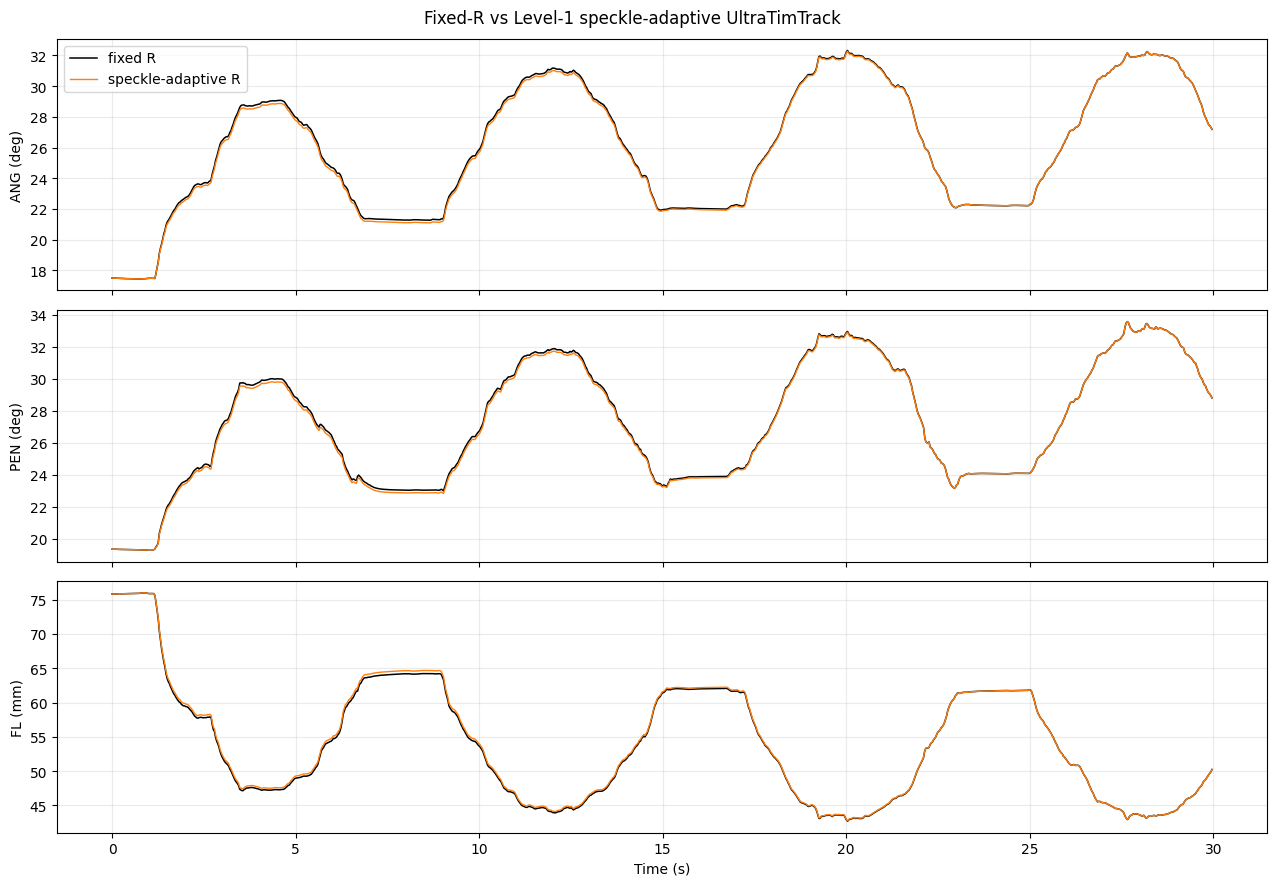

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
plot_items = [
    ('ANG (deg)', theta_fixed, theta_adaptive),
    ('PEN (deg)', pen_fixed, pen_adaptive),
    ('FL (mm)', length_fixed, length_adaptive),
]
for ax, (label, fixed, adap) in zip(axes, plot_items):
    ax.plot(time_conf, fixed, color='black', lw=1.1, label='fixed R')
    ax.plot(time_conf, adap, color='tab:orange', lw=1.0, label='speckle-adaptive R')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
axes[0].legend(loc='best')
fig.suptitle('Fixed-R vs Level-1 speckle-adaptive UltraTimTrack')
fig.tight_layout()
path = OUT / 'fixed_vs_adaptive_ANG_PEN_FL.png'
fig.savefig(path, dpi=170)
path

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/confidence_Rscale_ZNCC_validity.png')

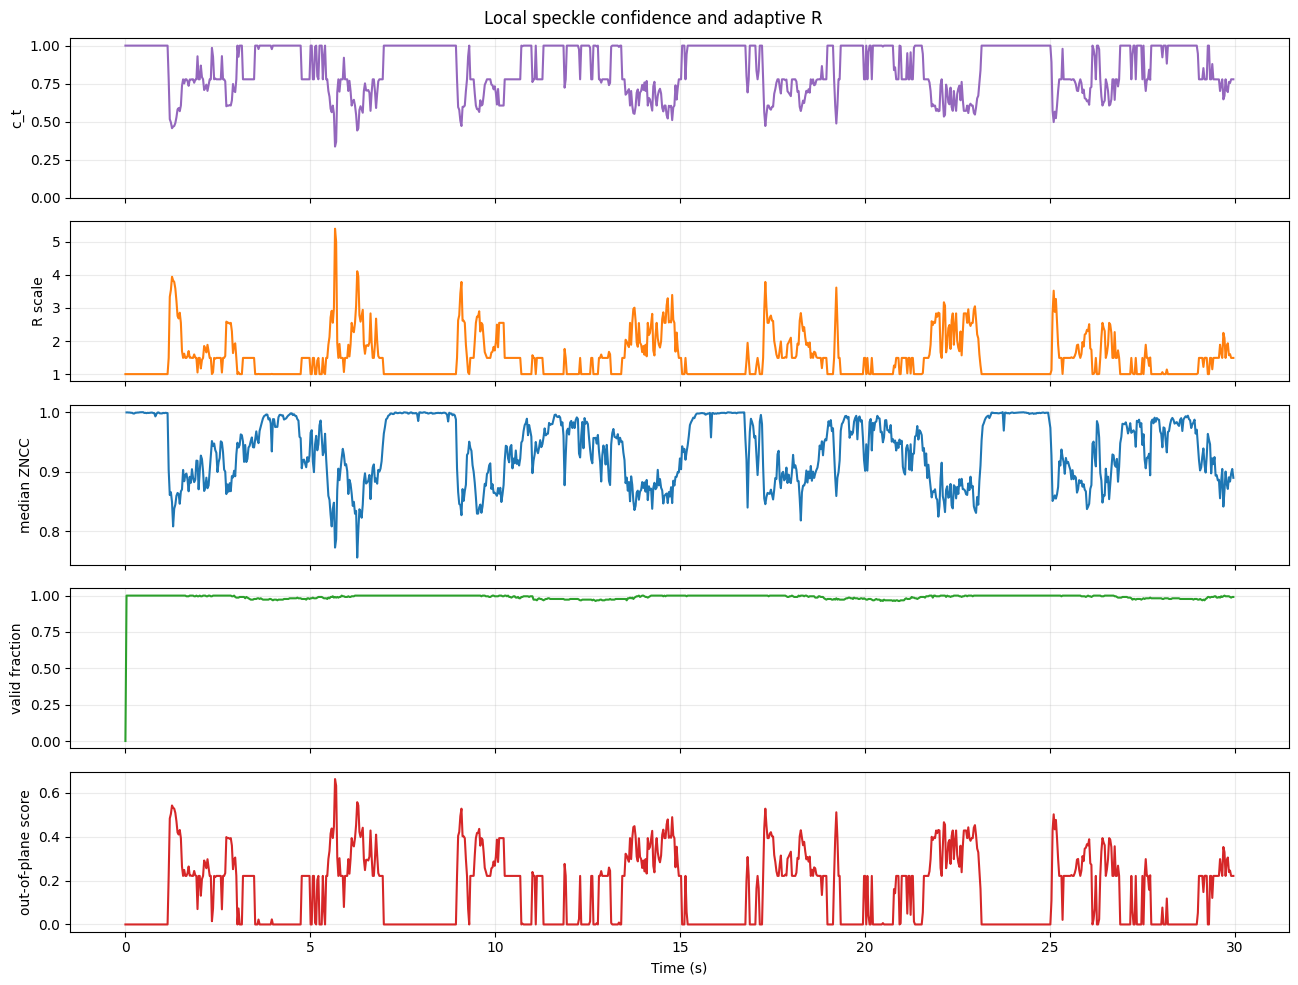

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(13, 10), sharex=True)
axes[0].plot(time_conf, conf_data['combined_confidence'], color='tab:purple')
axes[0].set_ylabel('c_t')
axes[0].set_ylim(0, 1.05)
axes[1].plot(time_conf, R_scale_conf, color='tab:orange')
axes[1].set_ylabel('R scale')
axes[2].plot(time_conf, conf_data['median_zncc'], color='tab:blue')
axes[2].set_ylabel('median ZNCC')
axes[3].plot(time_conf, conf_data['valid_fraction'], color='tab:green')
axes[3].set_ylabel('valid fraction')
axes[4].plot(time_conf, conf_data['out_of_plane_score'], color='tab:red')
axes[4].set_ylabel('out-of-plane score')
axes[4].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Local speckle confidence and adaptive R')
fig.tight_layout()
path = OUT / 'confidence_Rscale_ZNCC_validity.png'
fig.savefig(path, dpi=170)
path

## 15. Example Frame Overlay

The overlay shows sampled blocks, local displacement vectors, and local confidence color. This is a qualitative check that the confidence comes from sensible tissue motion rather than arbitrary image regions.

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/example_block_displacement_overlay.png')

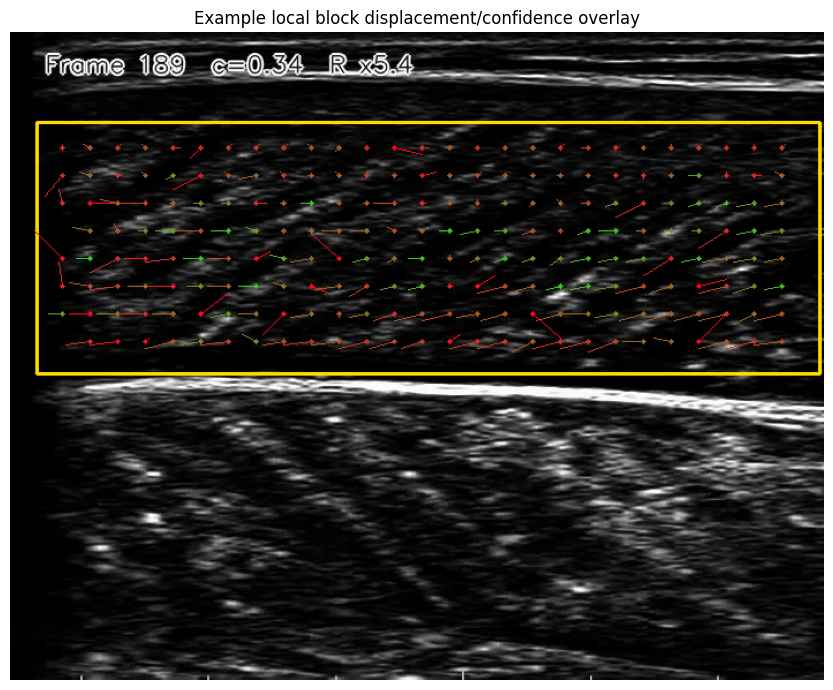

In [11]:
example_idx = int(np.nanargmax(R_scale_conf)) if np.any(np.isfinite(R_scale_conf)) else min(n_conf - 1, 1)
frames_for_overlay = read_gray_frames(VIDEO, limit=example_idx + 1)
frame = frames_for_overlay[example_idx]
vis = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
points = conf_data['sample_points']
disp = conf_data['displacements'][example_idx]
local_c = conf_data['local_confidence'][example_idx]
valid = conf_data['valid_mask'][example_idx]
x, y, w, h = fascicle_roi
cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 220, 0), 2)
for point, d, c, ok in zip(points, disp, local_c, valid):
    if not ok or not np.all(np.isfinite(d)):
        continue
    p0 = tuple(np.rint(point).astype(int))
    p1 = tuple(np.rint(point + 3.0 * d).astype(int))
    color = (int(255 * (1 - c)), int(255 * c), 40)
    cv2.circle(vis, p0, 2, color, -1)
    cv2.line(vis, p0, p1, color, 1)
cv2.putText(vis, f'Frame {example_idx}  c={conf_data["combined_confidence"][example_idx]:.2f}  R x{R_scale_conf[example_idx]:.1f}', (30, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 3, cv2.LINE_AA)
cv2.putText(vis, f'Frame {example_idx}  c={conf_data["combined_confidence"][example_idx]:.2f}  R x{R_scale_conf[example_idx]:.1f}', (30, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1, cv2.LINE_AA)

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(vis)
ax.set_axis_off()
ax.set_title('Example local block displacement/confidence overlay')
fig.tight_layout()
path = OUT / 'example_block_displacement_overlay.png'
fig.savefig(path, dpi=170)
path

## 15J. Optional Exploratory Strain Signal

This is **not validated** and is not a FEM/mechanics-informed model. It is only a sparse affine-gradient sanity check from the local displacement field. Treat `epsilon_f` as a research diagnostic, not an output measurement.

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/exploratory_fascicle_direction_strain.png')

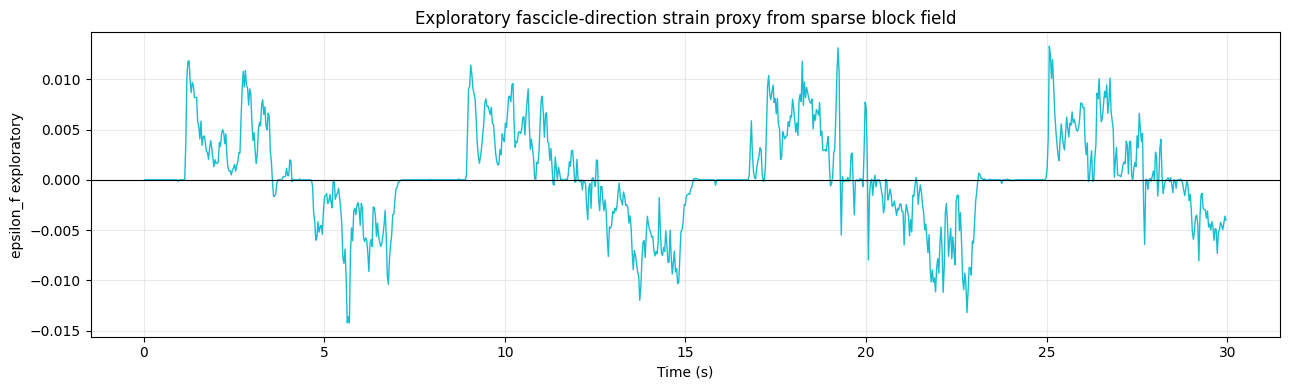

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(time_conf, conf_data['epsilon_f_exploratory'], color='tab:cyan', lw=1.0)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('epsilon_f exploratory')
ax.set_title('Exploratory fascicle-direction strain proxy from sparse block field')
ax.grid(True, alpha=0.25)
fig.tight_layout()
path = OUT / 'exploratory_fascicle_direction_strain.png'
fig.savefig(path, dpi=170)
path

## 17. Findings and Limitations

High confidence corresponds to high local ZNCC, coherent local displacement vectors, and enough valid blocks inside the muscle band. Confidence drops when local patches decorrelate, valid block fraction drops, or the displacement field becomes internally inconsistent.

In this Level-1 prototype, low confidence increases `R_geo,t`, so the final Kalman update trusts geometry detections less. This should reduce sensitivity to unreliable Hough/TimTrack measurements during noisy or out-of-plane frames, while preserving fixed-R UltraTimTrack as the baseline.

Limitations:

- This is not yet a mechanics/FEM model.
- The block field is sparse and purely image-based.
- Adaptive R needs manual/phantom validation before claiming improved accuracy.
- The strain proxy is exploratory only.

Functions worth moving into `ultrasound_tracker/speckle_confidence.py` later: `block_match`, muscle-band point sampling, local confidence aggregation, and the exploratory sparse-gradient diagnostic.